In [41]:
import pandas as pd
import numpy as np

In [42]:
df = pd.read_csv(r'C:\Users\PC\Desktop\محرومیت\data\labour_force_all_3.csv',low_memory=False)

In [43]:
import pandas as pd
import numpy as np

# ============================================
# 1. بارگذاری داده
# ============================================

# بارگذاری فایل CSV

# یا اگر دیتابیس داری
# import pyodbc
# conn = pyodbc.connect('DRIVER={SQL Server};SERVER=.;DATABASE=YourDB;Trusted_Connection=yes')
# df = pd.read_sql('SELECT * FROM dbo.[labour_force_all]', conn)

print("تعداد رکوردها:", len(df))
print("تعداد ستون‌ها:", len(df.columns))
print("\n--- 5 رکورد اول ---")
print(df.head())

# ============================================
# 2. شناسایی نوع متغیرها
# ============================================

# تعریف ستون‌های کلیدی (بر اساس داده‌های شما)
columns_mapping = {
    'pkey': {'name': 'شناسه', 'type': 'شناسه'},
    'year': {'name': 'سال', 'type': 'گسسته'},
    'F2_D03': {'name': 'سن', 'type': 'پیوسته'},
    'F2_D04': {'name': 'جنسیت', 'type': 'اسمی'},
    'F2_D05': {'name': 'وضعیت تاهل', 'type': 'اسمی'},
    'F2_D07': {'name': 'تحصیلات', 'type': 'ترتیبی'},
    'F2_D15': {'name': 'وضعیت فعالیت', 'type': 'اسمی'},
    'F2_D16': {'name': 'دلیل عدم فعالیت', 'type': 'اسمی'},
    'F2_D17': {'name': 'رشته تحصیلی', 'type': 'اسمی'},
    'F2_D18': {'name': 'کد تحصیلات ISCED', 'type': 'ترتیبی'},
    'F2_D19': {'name': 'وضعیت تاهل', 'type': 'اسمی'},
    'F3_D02': {'name': 'شاخص ۱', 'type': 'اسمی'},
    'F3_D03': {'name': 'شاخص ۲', 'type': 'اسمی'},
    'F3_D04': {'name': 'شاخص ۳', 'type': 'اسمی'},
    'F3_D05': {'name': 'شاخص ۴', 'type': 'اسمی'},
    'F3_D06': {'name': 'شاخص ۵', 'type': 'اسمی'},
    'F3_D07': {'name': 'شاخص ۶', 'type': 'اسمی'},
    'F3_D49': {'name': 'دسته غیرفعال', 'type': 'اسمی'},
    'IW_Yearly': {'name': 'وزن سالانه', 'type': 'پیوسته'},
    'ActivityStatus': {'name': 'وضعیت فعالیت', 'type': 'اسمی'},
    'education_group': {'name': 'گروه تحصیلی', 'type': 'اسمی'},
    'deprived': {'name': 'محرومیت', 'type': 'گسسته (دودویی)'},
    'household_number': {'name': 'شماره خانوار', 'type': 'گسسته'},
    'cluster_number': {'name': 'شماره خوشه', 'type': 'گسسته'},
    'urban_rural': {'name': 'شهری/روستایی', 'type': 'اسمی'},
    'province_code': {'name': 'کد استان', 'type': 'اسمی'},
    'sample_year': {'name': 'سال نمونه‌گیری', 'type': 'گسسته'},
}

# ============================================
# 3. تشخیص خودکار نوع متغیرها
# ============================================

def identify_variable_type(series):
    """
    تشخیص نوع متغیر بر اساس داده
    """
    # حذف مقادیر NaN
    clean_data = series.dropna()
    
    if len(clean_data) == 0:
        return 'نامشخص (همه NULL)'
    
    # بررسی نوع داده
    if pd.api.types.is_numeric_dtype(clean_data):
        unique_values = clean_data.nunique()
        total_values = len(clean_data)
        
        # اگر تعداد مقادیر منحصربه‌فرد کم باشد (کمتر از 10)، گسسته
        if unique_values <= 10:
            return 'گسسته'
        else:
            # اگر اعداد اعشاری دارند، پیوسته
            if clean_data.dtype == 'float64' and (clean_data % 1 != 0).any():
                return 'پیوسته'
            else:
                # بررسی کنید آیا اعداد فقط برچسب هستند
                return 'پیوسته (یا گسسته با تعداد زیاد)'
    
    elif pd.api.types.is_string_dtype(clean_data) or pd.api.types.is_object_dtype(clean_data):
        unique_values = clean_data.nunique()
        
        # اگر تعداد مقادیر منحصربه‌فرد کم باشد، اسمی
        if unique_values <= 10:
            return 'اسمی'
        else:
            # اگر مقادیر متنی باشند، اسمی
            return 'اسمی (با تعداد زیاد)'
    
    elif pd.api.types.is_datetime64_any_dtype(clean_data):
        return 'زمانی'
    
    else:
        return 'نامشخص'

# ============================================
# 4. ایجاد جدول شناسایی متغیرها
# ============================================

variable_info = []

for col in df.columns:
    # اطلاعات اولیه
    dtype = str(df[col].dtype)
    null_count = df[col].isna().sum()
    null_percent = (null_count / len(df)) * 100
    unique_count = df[col].nunique()
    
    # تشخیص نوع
    if col in columns_mapping:
        var_name = columns_mapping[col]['name']
        var_type = columns_mapping[col]['type']
    else:
        var_name = col
        var_type = identify_variable_type(df[col])
    
    # نمونه‌ای از مقادیر
    sample_values = df[col].dropna().head(5).tolist()
    
    variable_info.append({
        'نام_ستون': col,
        'نام_متغیر': var_name,
        'نوع_داده': dtype,
        'تعداد_NULL': null_count,
        'درصد_NULL': round(null_percent, 2),
        'تعداد_منحصربه‌فرد': unique_count,
        'نوع_متغیر': var_type,
        'نمونه_مقادیر': sample_values
    })

# تبدیل به DataFrame
var_df = pd.DataFrame(variable_info)

# ============================================
# 5. نمایش نتایج
# ============================================

print("\n" + "="*80)
print("شناسایی نوع متغیرها")
print("="*80)

# ستون‌های مورد نظر برای نمایش
display_cols = ['نام_ستون', 'نوع_داده', 'نوع_متغیر', 'تعداد_NULL', 'درصد_NULL', 'تعداد_منحصربه‌فرد', 'نمونه_مقادیر']
print(var_df[display_cols].to_string(index=False))

# ============================================
# 6. گروه‌بندی بر اساس نوع متغیر
# ============================================

print("\n" + "="*80)
print("گروه‌بندی متغیرها بر اساس نوع")
print("="*80)

var_groups = var_df.groupby('نوع_متغیر')['نام_ستون'].apply(list).to_dict()

for var_type, columns in var_groups.items():
    print(f"\n{var_type}:")
    for col in columns:
        print(f"  - {col}")

# ============================================
# 7. ذخیره نتایج
# ============================================

# ذخیره جدول شناسایی به CSV
var_df.to_csv('variable_types_report.csv', index=False, encoding='utf-8-sig')
print("\nگزارش ذخیره شد: variable_types_report.csv")

# ============================================
# 8. تعریف دقیق متغیرها بر اساس رویکرد انسان‌شناسی
# ============================================

print("\n" + "="*80)
print("تعریف نهایی متغیرها بر اساس شاخص‌های پنج‌گانه")
print("="*80)

final_vars = {
    'متغیرهای مستقل (شاخص‌های پنج‌گانه)': {
        'جنسیت': {'ستون': 'F2_D04', 'نوع': 'اسمی', 'مقادیر': '1=مرد, 2=زن'},
        'مکان': {'ستون': 'urban_rural', 'نوع': 'اسمی', 'مقادیر': '0=روستایی, 1=شهری'},
        'تحصیلات': {'ستون': 'education_group', 'نوع': 'اسمی', 'مقادیر': 'گروه‌های ISCED'},
        'وضعیت تاهل': {'ستون': 'F2_D19', 'نوع': 'اسمی', 'مقادیر': '1=مجرد, 2=متأهل, ...'},
        'سن': {'ستون': 'F2_D03', 'نوع': 'پیوسته', 'مقادیر': '15-99 سال'},
    },
    'متغیر وابسته': {
        'محرومیت': {'ستون': 'deprived', 'نوع': 'گسسته (دودویی)', 'مقادیر': '0=غیرمحروم, 1=محروم'},
    },
    'متغیرهای کنترل': {
        'سال': {'ستون': 'year', 'نوع': 'گسسته', 'مقادیر': '1401, 1402, 1403'},
        'وزن': {'ستون': 'IW_Yearly', 'نوع': 'پیوسته', 'مقادیر': 'وزن نمونه‌گیری'},
    }
}

for category, vars_dict in final_vars.items():
    print(f"\n{category}:")
    for name, info in vars_dict.items():
        print(f"  {name}: {info}")

# ============================================
# 9. آمار توصیفی برای متغیرهای کلیدی
# ============================================

print("\n" + "="*80)
print("آمار توصیفی متغیرهای کلیدی")
print("="*80)

# سن
if 'F2_D03' in df.columns:
    print("\nسن (F2_D03):")
    print(df['F2_D03'].describe())

# محرومیت
if 'deprived' in df.columns:
    print("\nمحرومیت (deprived):")
    print(df['deprived'].value_counts())
    print(f"درصد محرومیت: {df['deprived'].mean()*100:.2f}%")

# جنسیت
if 'F2_D04' in df.columns:
    print("\nجنسیت (F2_D04):")
    print(df['F2_D04'].value_counts())

# تحصیلات
if 'education_group' in df.columns:
    print("\nگروه تحصیلی (education_group):")
    print(df['education_group'].value_counts())

تعداد رکوردها: 1509233
تعداد ستون‌ها: 44

--- 5 رکورد اول ---
   Unnamed: 0       pkey  NobatAmargiri F2_D03  F2_D04 F2_D05  F2_D06  F2_D07  \
0           0  125103261              3      1       1     03    47.0    54.0   
1           1  125103261              3      2       2     03    58.0    43.0   
2           2  125103261              3      3       2     03    80.0    21.0   
3           3  125103261              3      3       1     08    85.0    16.0   
4           4  125103262              2      1       1     09    71.0    29.0   

   F2_D15  F2_D16  ...  cluster_number urban_rural province_code  sample_year  \
0       2       1  ...              32           1            25            1   
1       2       1  ...              32           1            25            1   
2       1       1  ...              32           1            25            1   
3       1       1  ...              32           1            25            1   
4       2       1  ...              32        

تعداد کل رکوردها: 1509233
تعداد کل ستون‌ها: 44

📊 درصد مقادیر گمشده در هر ستون:
                  تعداد_گمشده  درصد_گمشده         وضعیت
F3_D07                1491441   98.821123  🔴 بسیار زیاد
F3_D38                1481973   98.193785  🔴 بسیار زیاد
F3_D37MAH             1481963   98.193122  🔴 بسیار زیاد
F3_D24                 953928   63.206145  🔴 بسیار زیاد
F3_D13                 953918   63.205483  🔴 بسیار زیاد
F3_D11                 953918   63.205483  🔴 بسیار زیاد
F3_D09                 953918   63.205483  🔴 بسیار زیاد
education_group        860998   57.048713  🔴 بسیار زیاد
F2_D18                 860238   56.998356  🔴 بسیار زیاد
F3_D47                 604191   40.032984  🔴 بسیار زیاد
F3_D33                 603826   40.008799  🔴 بسیار زیاد
F3_D31                 555315   36.794517  🔴 بسیار زیاد
F3_D06                 537523   35.615641  🔴 بسیار زیاد
F3_D05                 533201   35.329270  🔴 بسیار زیاد
F3_D04                 530513   35.151166  🔴 بسیار زیاد
F3_D03                 5

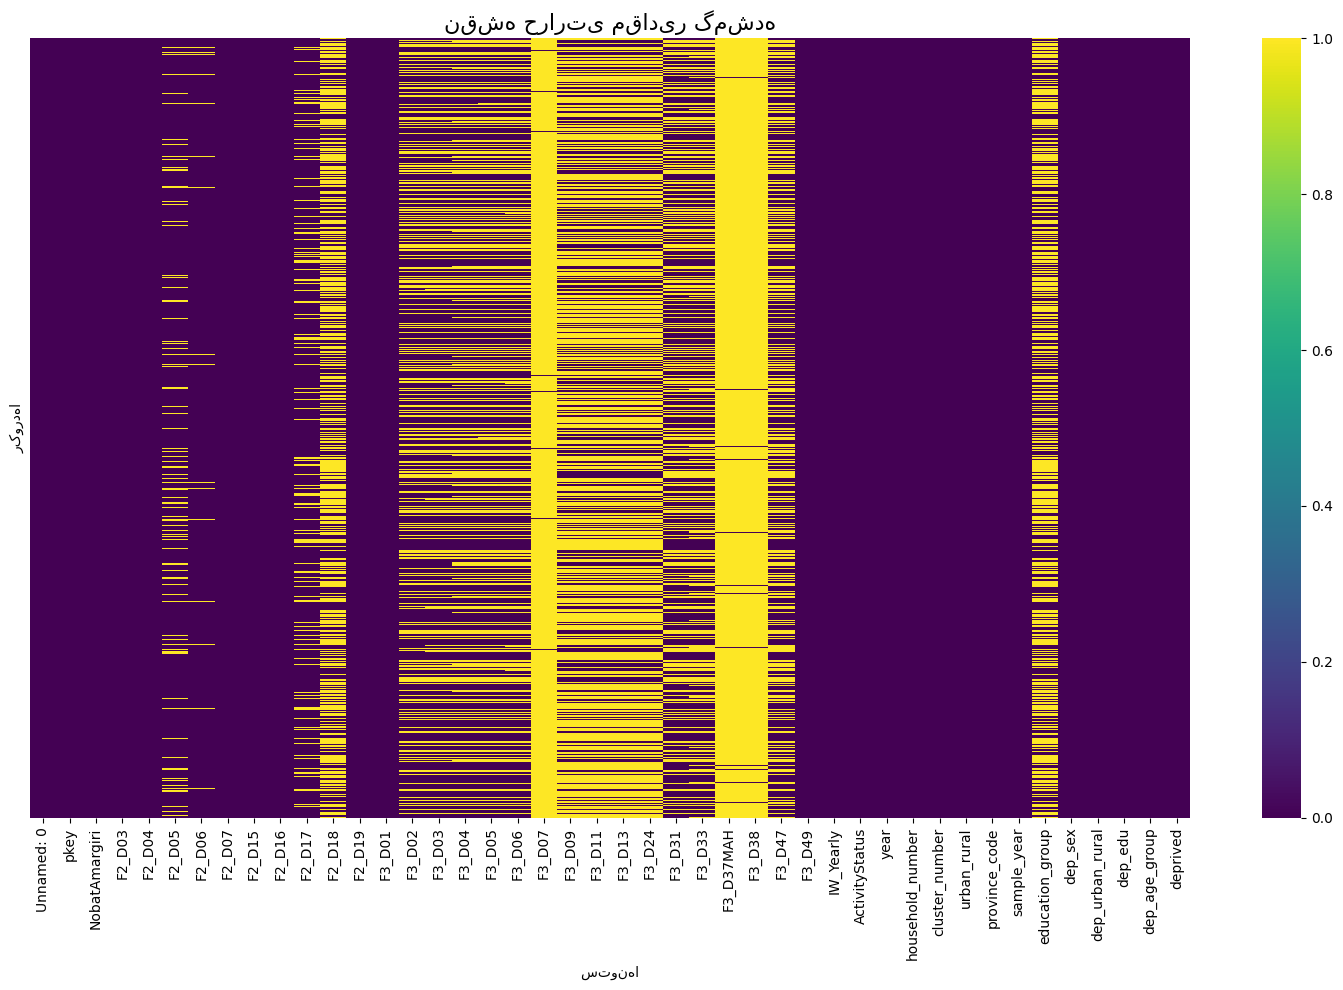

In [45]:
import pandas as pd
import numpy as np

# ============================================
# 1. بارگذاری داده
# ============================================

# بارگذاری فایل CSV

print("="*80)
print("تعداد کل رکوردها:", len(df))
print("تعداد کل ستون‌ها:", len(df.columns))
print("="*80)

# ============================================
# 2. محاسبه درصد مقادیر گمشده
# ============================================

# محاسبه تعداد و درصد مقادیر گمشده برای هر ستون
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# ایجاد DataFrame از نتایج
missing_df = pd.DataFrame({
    'تعداد_گمشده': missing_data,
    'درصد_گمشده': missing_percent
})

# مرتب‌سازی بر اساس درصد گمشده (نزولی)
missing_df = missing_df.sort_values('درصد_گمشده', ascending=False)

# اضافه کردن ستون وضعیت
def get_status(percent):
    if percent == 0:
        return '✅ کامل'
    elif percent < 1:
        return '🟢 کم'
    elif percent < 5:
        return '🟡 متوسط'
    elif percent < 20:
        return '🟠 زیاد'
    else:
        return '🔴 بسیار زیاد'

missing_df['وضعیت'] = missing_df['درصد_گمشده'].apply(get_status)

# ============================================
# 3. نمایش نتایج
# ============================================

print("\n📊 درصد مقادیر گمشده در هر ستون:")
print("="*80)
print(missing_df.to_string())

# ============================================
# 4. خلاصه آماری
# ============================================

print("\n" + "="*80)
print("📈 خلاصه آماری مقادیر گمشده:")
print("="*80)

total_cells = df.size
total_missing = df.isnull().sum().sum()
total_non_missing = total_cells - total_missing
missing_percent_total = (total_missing / total_cells) * 100

print(f"کل سلول‌ها:        {total_cells:,}")
print(f"مقادیر غیرگمشده:   {total_non_missing:,}")
print(f"مقادیر گمشده:      {total_missing:,}")
print(f"درصد کل گمشده:     {missing_percent_total:.2f}%")

# ============================================
# 5. توزیع وضعیت گمشده
# ============================================

print("\n" + "="*80)
print("📊 توزیع ستون‌ها بر اساس درصد گمشده:")
print("="*80)

status_counts = missing_df['وضعیت'].value_counts()
for status, count in status_counts.items():
    print(f"  {status}: {count} ستون")

# ============================================
# 6. ستون‌های با بیشترین و کمترین گمشده
# ============================================

print("\n" + "="*80)
print("🔴 ۵ ستون با بیشترین درصد گمشده:")
print("="*80)
print(missing_df.head(5)[['تعداد_گمشده', 'درصد_گمشده', 'وضعیت']])

print("\n" + "="*80)
print("✅ ۵ ستون با کمترین درصد گمشده:")
print("="*80)
print(missing_df.tail(5)[['تعداد_گمشده', 'درصد_گمشده', 'وضعیت']])

# ============================================
# 7. بررسی ستون‌های کلیدی برای تحلیل
# ============================================

print("\n" + "="*80)
print("🎯 وضعیت گمشده در ستون‌های کلیدی:")
print("="*80)

key_columns = ['F2_D03', 'F2_D04', 'F2_D19', 'F2_D18', 'F2_D15', 
               'ActivityStatus', 'IW_Yearly', 'deprived', 'education_group']

for col in key_columns:
    if col in df.columns:
        missing = df[col].isnull().sum()
        percent = (missing / len(df)) * 100
        status = get_status(percent)
        print(f"  {col:20s}: {missing:8,} ({percent:5.2f}%) {status}")

# ============================================
# 8. ذخیره گزارش
# ============================================

missing_df.to_csv('missing_data_report.csv', encoding='utf-8-sig')
print("\n✅ گزارش ذخیره شد: missing_data_report.csv")

# ============================================
# 9. ماتریس حرارتی (Heatmap) - اختیاری
# ============================================

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # ایجاد نقشه حرارتی
    plt.figure(figsize=(15, 10))
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('نقشه حرارتی مقادیر گمشده', fontsize=16)
    plt.xlabel('ستون‌ها')
    plt.ylabel('رکوردها')
    plt.tight_layout()
    plt.savefig('missing_heatmap.png', dpi=150)
    print("✅ نقشه حرارتی ذخیره شد: missing_heatmap.png")
except:
    print("⚠️ برای نمایش نقشه حرارتی، matplotlib و seaborn را نصب کن")

In [ ]:
df.duplicated()